# Proyek Klasifikasi Gambar: [Tomato Leaves Dataset](https://www.kaggle.com/datasets/ashishmotwani/tomato)
- **Nama:** TanamJo

## Import Semua Packages/Library yang Digunakan

In [ ]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

!pip install --upgrade tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
db-dtypes 1.4.3 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.34.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


## Data Preparation

### Data Loading

In [ ]:
# Import module yang disediakan google colab untuk kebutuhan upload file

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"avelticoalu","key":"519745e75a28acc76c1ec774cce1cc17"}'}

In [ ]:
# Download kaggle dataset and unzip the file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d ashishmotwani/tomato
!mkdir tomato-leaves-dataset
!mv tomato.zip tomato-leaves-dataset/
!unzip -d tomato-leaves-dataset/ tomato-leaves-dataset/tomato.zip
!rm tomato-leaves-dataset/tomato.zip

Streaming output truncated to the last 5000 lines.
  inflating: tomato-leaves-dataset/valid/Late_blight/9aaf4a7d-12ac-457a-a18c-1f7ea13065de___RS_Late.B 5179.JPG  
  inflating: tomato-leaves-dataset/valid/Late_blight/9afc2537-1b13-4c25-b5ed-5b8de511b0ab___GHLB2 Leaf 9033.JPG  
  inflating: tomato-leaves-dataset/valid/Late_blight/9bb49d22-976d-40c3-bc9a-bff5cbbd8e28___RS_Late.B 5057.JPG  
  inflating: tomato-leaves-dataset/valid/Late_blight/9c274db5-2f89-4f3c-b9e2-4d5ebc54ddad___GHLB2 Leaf 9096.JPG  
  inflating: tomato-leaves-dataset/valid/Late_blight/9c726f4e-045b-4080-b53d-d7e66d45bcb1___RS_Late.B 4876.JPG  
  inflating: tomato-leaves-dataset/valid/Late_blight/9e5dd34f-124c-4a64-ba9f-77c8d05faa9c___GHLB2 Leaf 8749.JPG  
  inflating: tomato-leaves-dataset/valid/Late_blight/9e633823-3dde-450c-8172-733021e4dff0___RS_Late.B 6414.JPG  
  inflating: tomato-leaves-dataset/valid/Late_blight/9ecb8001-2f48-4487-b287-535dbcfb5c2f___RS_Late.B 6206.JPG  
  inflating: tomato-leaves-dataset/valid/L

In [ ]:
# Direktori awal untuk train dan test
train_dir = "tomato-leaves-dataset/train"
test_dir = "tomato-leaves-dataset/valid"

# Direktori baru untuk dataset gabungan
combined_dir = "tomato-leaves-dataset/dataset"

In [ ]:
# Buat direktori baru untuk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

In [ ]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
    category_dir = os.path.join(train_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
    category_dir = os.path.join(test_dir, category)
    if os.path.isdir(category_dir):
        shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

In [ ]:
import matplotlib.pyplot as plt

# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
leaves_image = {}

# Tentukan path sumber train
path_sub = "tomato-leaves-dataset/train"
for i in os.listdir(path_sub):
    leaves_image[i] = os.listdir(os.path.join(path_sub, i))

In [ ]:
print(leaves_image)

{'Septoria_leaf_spot': ['8a7b0bc4-2641-4674-9ce7-6b69ab55f388___Matt.S_CG 6816.JPG', 'SS_ (972).jpg', '0bcb24a9-bf45-4008-b9df-1c729f977b17___Matt.S_CG 7835_180deg.JPG', 'SS_ (511).jpg', '212c8703-4c56-4c2b-a1d0-1047a758ca93___Keller.St_CG 1786.JPG', 'b49c2ffd-6fa4-4ab8-8458-f4cc444c1325___Matt.S_CG 6007.JPG', '6447731_orig_jpg.rf.3f8a3c42daf37a870a2808e0140a26e6.jpg', '07dd57ec-cbf0-4fc1-b680-6b3226da51e4___JR_Sept.L.S 8524.JPG', 'Gls23_lower.jpg', '18b450ff-ae57-4873-9c73-7ebef0b659cd___Matt.S_CG 0953.JPG', '87ba14ab-3b74-407b-977e-237258eb6947___Matt.S_CG 6787.JPG', 'Gls32_change_270.jpg', '23e043f7-9634-44e5-a49a-25d4ee7e151a___Matt.S_CG 7798.JPG', 'SS_ (995).jpg', '9102ff1d-7934-408e-bc0b-ca2694f46b76___Matt.S_CG 2870.JPG', 'b87ed565-d3b3-4f69-9a9e-9b742e376110___JR_Sept.L.S 8403.JPG', 'af7fb316-b07c-4ff1-a724-72149184defb___Matt.S_CG 5981.JPG', 'Gls58_hight.jpg', 'Gls12_hight.jpg', 'Gls77_change_90.jpg', 'Septoria-Leaf-Spot_jpg.rf.bf8b552dbd97ffb4e26716b9491b6957.jpg', 'septoria2

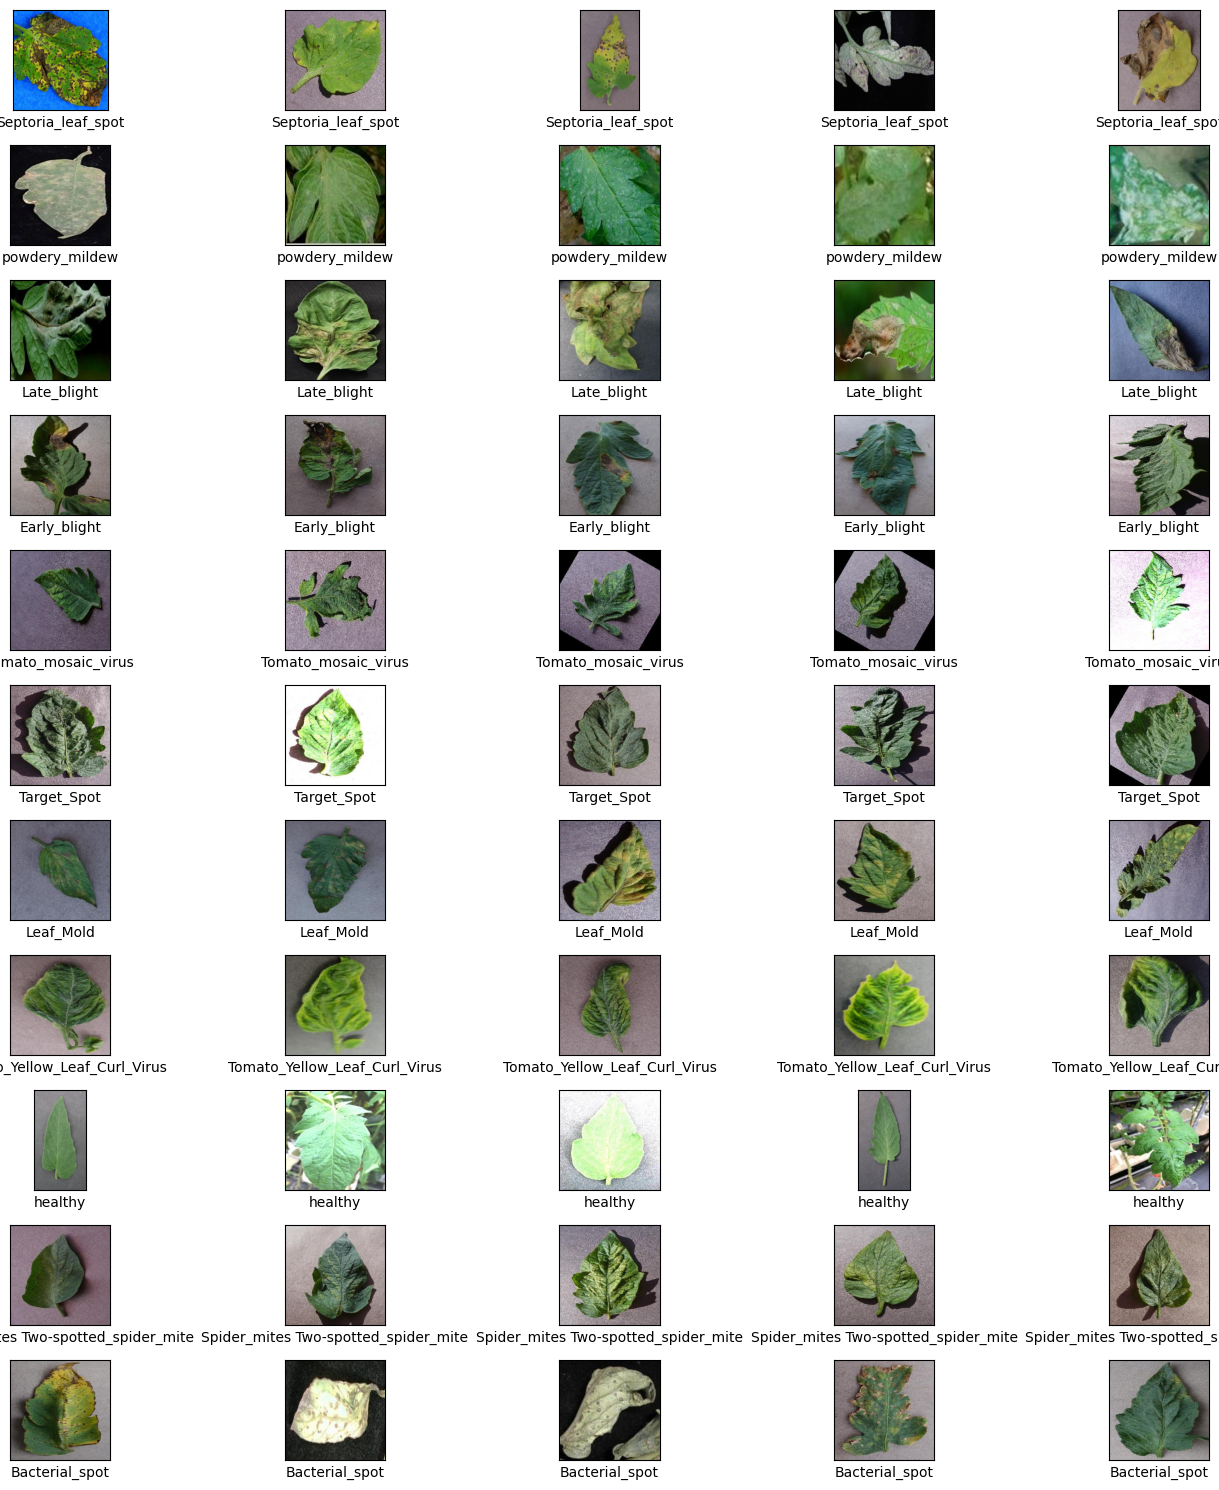

In [ ]:
# Menampilkan secara acak 5 gambar di bawah setiap dari setiap kelas dari data.
# Anda akan melihat gambar yang berbeda setiap kali kode ini dijalankan.
path_sub = "tomato-leaves-dataset/dataset/"

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(leaves_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(leaves_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path)
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

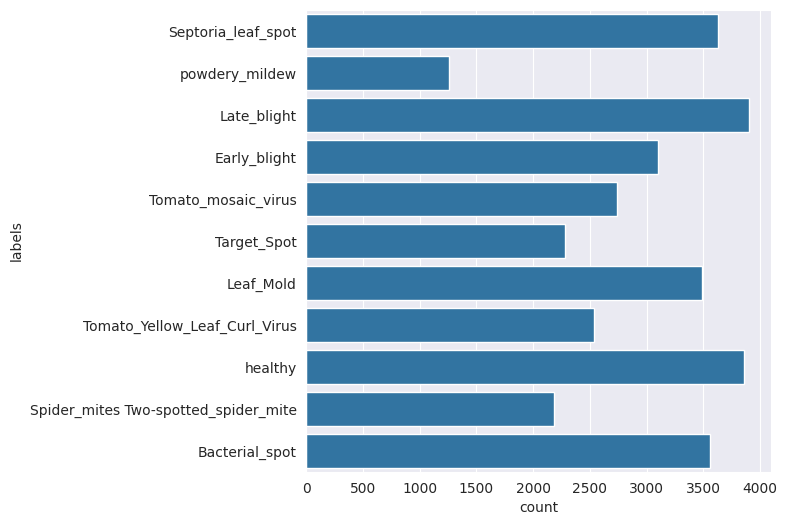

In [ ]:
import seaborn as sns

# Definisikan path sumber
leaves_path = "tomato-leaves-dataset/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for path, subdirs, files in os.walk(leaves_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

### Data Preprocessing

#### Split Dataset

In [ ]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'tomato-leaves-dataset/dataset/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
Bacterial_spot,3558
Early_blight,3098
Late_blight,3905
Leaf_Mold,3493
Septoria_leaf_spot,3628
Spider_mites Two-spotted_spider_mite,2182
Target_Spot,2284
Tomato_Yellow_Leaf_Curl_Virus,2537
Tomato_mosaic_virus,2737


In [ ]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

In [ ]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [ ]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "tomato-leaves-dataset/dataset/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels                              
test   Bacterial_spot                           697
       Early_blight                             623
       Late_blight                              785
       Leaf_Mold                                668
       Septoria_leaf_spot                       690
       Spider_mites Two-spotted_spider_mite     439
       Target_Spot                              478
       Tomato_Yellow_Leaf_Curl_Virus            531
       Tomato_mosaic_virus                      590
       healthy                                  742
       powdery_mildew                           264
train  Bacterial_spot                          2861
       Early_blight                            2475
       Late_blight                             3120
       Leaf_Mold                               2825
       Septoria_leaf_spot                      2938
       Spider_mites Two-spotted_spider_mite    1743
       Target_Spot                             1806
       Tomato_Yello

In [ ]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

In [ ]:
# Definisikan direktori training dan test
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"

labels = ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite',
          'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']

# Train
for label in labels:
  print(f"Total number of {label} images in training set:",len(os.listdir(os.path.join(TRAIN_DIR + label))))

print()

# Test
for label in labels:
  print(f"Total number of {label} images in test set:",len(os.listdir(os.path.join(TEST_DIR + label))))


Total number of Bacterial_spot images in training set: 2861
Total number of Early_blight images in training set: 2475
Total number of Late_blight images in training set: 3120
Total number of Leaf_Mold images in training set: 2825
Total number of Septoria_leaf_spot images in training set: 2938
Total number of Spider_mites Two-spotted_spider_mite images in training set: 1743
Total number of Target_Spot images in training set: 1806
Total number of Tomato_Yellow_Leaf_Curl_Virus images in training set: 2006
Total number of Tomato_mosaic_virus images in training set: 2147
Total number of healthy images in training set: 3114
Total number of powdery_mildew images in training set: 992

Total number of Bacterial_spot images in test set: 697
Total number of Early_blight images in test set: 623
Total number of Late_blight images in test set: 785
Total number of Leaf_Mold images in test set: 668
Total number of Septoria_leaf_spot images in test set: 690
Total number of Spider_mites Two-spotted_spid

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input

# Buat objek ImageDataGenerator yang menormalkan gambar
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 20% sebagai test
)


train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(224, 224),
                                              class_mode='categorical',
                                              subset='training',
                                              shuffle=True)


test_generator = datagen.flow_from_directory(TEST_DIR,
                                             batch_size=32,
                                             target_size=(224, 224),
                                             class_mode='categorical',
                                             subset='validation',
                                             shuffle=False)

print("\nTotal images in training set: ", train_generator.n)
print("Total images in test set: ", test_generator.n)
print("Classes used:", train_generator.class_indices)

Found 20825 images belonging to 11 classes.
Found 1297 images belonging to 11 classes.

Total images in training set:  20825
Total images in test set:  1297
Classes used: {'Bacterial_spot': 0, 'Early_blight': 1, 'Late_blight': 2, 'Leaf_Mold': 3, 'Septoria_leaf_spot': 4, 'Spider_mites Two-spotted_spider_mite': 5, 'Target_Spot': 6, 'Tomato_Yellow_Leaf_Curl_Virus': 7, 'Tomato_mosaic_virus': 8, 'healthy': 9, 'powdery_mildew': 10}


## Modelling

In [ ]:
from tensorflow.keras.applications import VGG16

# Load VGG16 base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze convolutional base
for layer in base_model.layers:
    layer.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Input

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(len(train_generator.class_indices), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=x)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │         2,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,843 (56.64 MB)

 Trainable params: 134,155 (524.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
class AccuracyThresholdCallback(Callback):
    def __init__(self, threshold=0.95):
        super().__init__()
        self.threshold = threshold

    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        if val_acc is not None and val_acc >= self.threshold:
            print(f"\n✅ Reached {val_acc:.2%} validation accuracy. Stopping training.")
            self.model.stop_training = True

In [ ]:
callback2 = keras.callbacks.EarlyStopping(monitor='accuracy', patience=3)

In [ ]:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[AccuracyThresholdCallback(threshold=0.95), callback2]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
651/651 ━━━━━━━━━━━━━━━━━━━━ 383s 566ms/step - accuracy: 0.4241 - loss: 2.0464 - val_accuracy: 0.7826 - val_loss: 0.6912
Epoch 2/50
651/651 ━━━━━━━━━━━━━━━━━━━━ 349s 535ms/step - accuracy: 0.6730 - loss: 0.9531 - val_accuracy: 0.8165 - val_loss: 0.5588
Epoch 3/50
651/651 ━━━━━━━━━━━━━━━━━━━━ 359s 551ms/step - accuracy: 0.7333 - loss: 0.7855 - val_accuracy: 0.8389 - val_loss: 0.4769
Epoch 4/50
651/651 ━━━━━━━━━━━━━━━━━━━━ 352s 541ms/step - accuracy: 0.7513 - loss: 0.7260 - val_accuracy: 0.8527 - val_loss: 0.4387
Epoch 5/50
651/651 ━━━━━━━━━━━━━━━━━━━━ 347s 533ms/step - accuracy: 0.7736 - loss: 0.6552 - val_accuracy: 0.8365 - val_loss: 0.4358
Epoch 6/50
651/651 ━━━━━━━━━━━━━━━━━━━━ 350s 537ms/step - accuracy: 0.7819 - loss: 0.6204 - val_accuracy: 0.8666 - val_loss: 0.3962
Epoch 7/50
651/651 ━━━━━━━━━━━━━━━━━━━━ 352s 541ms/step - accuracy: 0.7939 - loss: 0.5892 - val_accuracy: 0.8604 - val_loss: 0.4023
Epoch 8/50
651/651 ━━━━━━━━━━━━━━━━━━━━ 389s 551ms/step - accuracy: 0.7943 -

## Evaluasi dan Visualisasi

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'\nTest loss: {test_loss:.4f}')

41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 459ms/step - accuracy: 0.8852 - loss: 0.3151

Test accuracy: 0.8820

Test loss: 0.3326


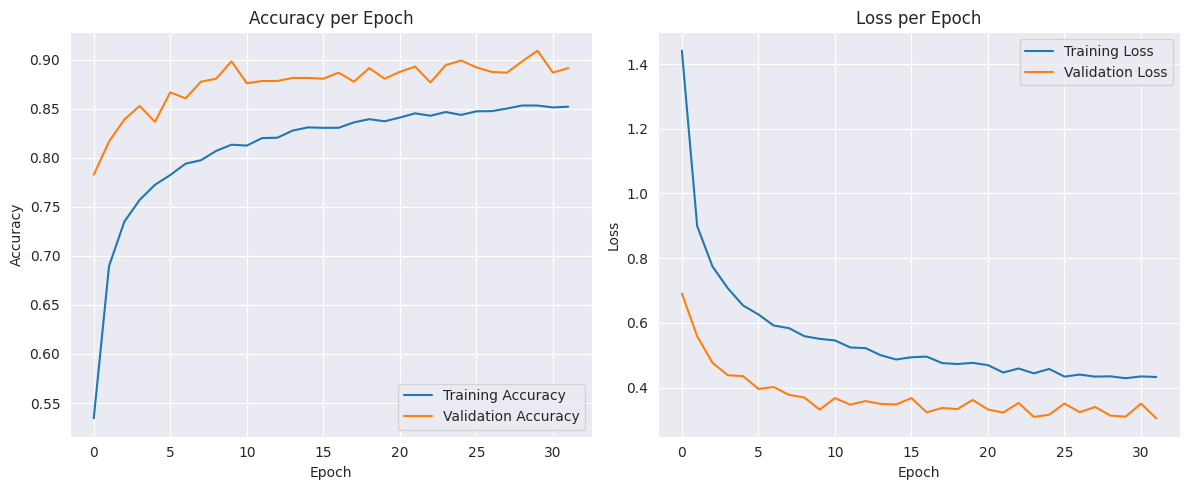

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = test_generator.classes
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_generator.class_indices.keys())

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("Classification Report:")
print(report)

41/41 ━━━━━━━━━━━━━━━━━━━━ 21s 498ms/step
Classification Report:
                                      precision    recall  f1-score   support

                      Bacterial_spot       0.92      0.94      0.93       139
                        Early_blight       0.90      0.75      0.82       124
                         Late_blight       0.90      0.94      0.92       157
                           Leaf_Mold       0.87      0.95      0.91       133
                  Septoria_leaf_spot       0.81      0.83      0.82       138
Spider_mites Two-spotted_spider_mite       0.88      0.89      0.88        87
                         Target_Spot       0.77      0.88      0.82        95
       Tomato_Yellow_Leaf_Curl_Virus       0.96      0.96      0.96       106
                 Tomato_mosaic_virus       0.94      0.97      0.95       118
                             healthy       0.97      0.92      0.94       148
                      powdery_mildew       0.97      0.71      0.82        5

###Simpan Model

In [ ]:
model.save("my_model.keras")

In [ ]:
model.export("saved_model_dir")

Saved artifact at 'saved_model_dir'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  134764858106768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764858107536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802285904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802284944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764858107344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802285712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802285328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802284752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802286864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802287824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13476480228724

In [ ]:
import shutil

# Zip the SavedModel directory
shutil.make_archive(
    base_name="saved_model_zip",  # Output filename (without .zip)
    format="zip",                 # Compression format
    root_dir="saved_model_dir"     # Folder to zip (contains saved_model.pb)
)

print("Zipped to: saved_model_zip.zip")

Zipped to: saved_model_zip.zip


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpthkno39r'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 11), dtype=tf.float32, name=None)
Captures:
  134764858106768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764858107536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802285904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802284944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764858107344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802285712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802285328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802284752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802286864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134764802287824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1347648022872

In [ ]:
# Ambil urutan kelas dari train_generator
class_indices = train_generator.class_indices

# Urutkan berdasarkan index (karena dictionary awalnya: {label: index})
sorted_labels = sorted(class_indices.items(), key=lambda x: x[1])
label_list = [label for label, idx in sorted_labels]

# Tampilkan daftar label
print("List of labels in training order:")
print(label_list)

# Simpan ke label.txt
with open("label.txt", "w") as f:
    for label in label_list:
        f.write(label + "\n")

List of labels in training order:
['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite', 'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']


In [ ]:
!unzip saved_model_dir /content/saved_model_zip.zip

Archive:  /content/saved_model_zip.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of /content/saved_model_zip.zip or
        /content/saved_model_zip.zip.zip, and cannot find /content/saved_model_zip.zip.ZIP, period.


In [ ]:
# Convert directly from .h5 to TFJS
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model  \
    /content/saved_model_dir \
    tfjs_model

2025-06-11 12:22:35.861407: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749644555.883780   49250 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749644555.890519   49250 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-06-11 12:22:43.085207: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1749644563.085380   49250 gpu_device.cc:2022] Created device /job:localhost/replica:0/task

In [ ]:
import shutil

# Zip the TFJS model directory
shutil.make_archive(
    base_name="tfjs_graph_model",  # Output filename (without .zip)
    format="zip",               # Compression format
    root_dir="/content/tfjs_model"   # Folder to zip
)

print("Zipped to: tfjs_graph_model.zip")

Zipped to: tfjs_graph_model.zip


In [ ]:
from google.colab import files
import os

# Assuming you have a file named 'my_model.keras' in your Colab environment
file_path = 'tfjs_graph_model.zip'
# Check if the file exists
if os.path.exists(file_path):
  # Download the file
  files.download(file_path)
  print(f"Downloaded: {file_path}")
else:
  print(f"File not found: {file_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: tfjs_graph_model.zip


In [ ]:
from google.colab import files
import os

# Assuming you have a file named 'my_model.keras' in your Colab environment
file_path = 'label.txt'
# Check if the file exists
if os.path.exists(file_path):
  # Download the file
  files.download(file_path)
  print(f"Downloaded: {file_path}")
else:
  print(f"File not found: {file_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: label.txt


In [ ]:
from google.colab import files
import os

# Assuming you have a file named 'my_model.keras' in your Colab environment
file_path = 'my_model.keras'
# Check if the file exists
if os.path.exists(file_path):
  # Download the file
  files.download(file_path)
  print(f"Downloaded: {file_path}")
else:
  print(f"File not found: {file_path}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: my_model.keras


## Inference

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
from google.colab import files

# Definisikan daftar label sesuai urutan training
selected_classes = ['Bacterial_spot', 'Early_blight', 'Late_blight', 'Leaf_Mold', 'Septoria_leaf_spot', 'Spider_mites Two-spotted_spider_mite',
          'Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus', 'Tomato_mosaic_virus', 'healthy', 'powdery_mildew']

# Load model
model = load_model("my_model.keras")

def predict_image(img_path):
    # Load dan resize gambar
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Preprocessing sesuai VGG16
    img_array = preprocess_input(img_array)

    # Prediksi
    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions)
    predicted_label = selected_classes[predicted_index]
    confidence = predictions[0][predicted_index]

    print(f"✅ Predicted class: {predicted_label}")
    print(f"🔍 Confidence: {confidence:.2%}")

    return predicted_label, confidence

# Contoh penggunaan
uploaded_file = files.upload()
predict_image(list(uploaded_file.keys())[0])

Saving images (1).jpg to images (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
✅ Predicted class: Late_blight
🔍 Confidence: 75.34%


('Late_blight', np.float32(0.7534132))